In [3]:
from physics.probability.walks import random_walk as rw

In [4]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import numpy as np

In [5]:
N = 10**4
D = 1/3
steps = 1000

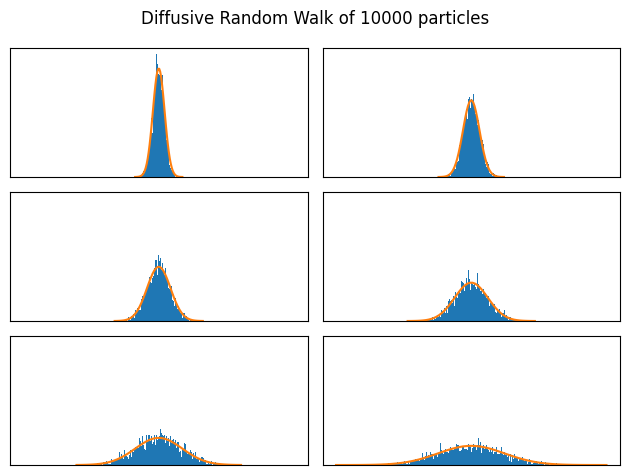

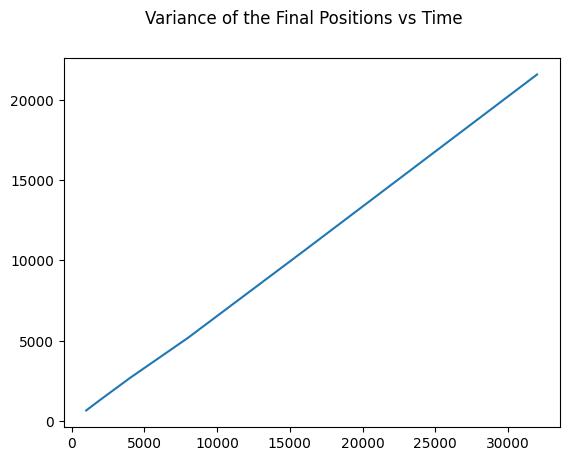

In [6]:
N = 10**4
D = 1/3
steps = 1000
times = np.array([1,2,4,8,16,32]) * steps
fig, axes = subplots(3,2, sharey=True, sharex=True)
fig.suptitle(f"Diffusive Random Walk of {N} particles")
faxes = axes.flat
vars = []
for axis, t in zip(faxes, times):
    end_state = rw.one_dim_sim(N, t)
    furthest = np.max(np.abs(end_state))
    range_x = np.linspace(-furthest, furthest)
    analysis = rw.one_dim_analytical(range_x, t, D)
    axis.hist(end_state, bins=int((furthest * 2) + 1) ,range=(-furthest, furthest), density=True)
    axis.plot(range_x, analysis)
    axis.get_xaxis().set_ticks([])
    axis.get_yaxis().set_ticks([])
    var = np.var(end_state)
    vars.append(var)
plt.tight_layout()
fig, axis = subplots()
fig.suptitle(f"Variance of the Final Positions vs Time")
axis.plot(times, vars)

In [7]:
A = np.array([0, 1, 2])

B = np.array([[ 0,  1,  2,  3],
              [ 4,  5,  6,  7],
              [ 8,  9, 10, 11]])

In [10]:
A[:,np.newaxis]

array([[0],
       [1],
       [2]])

In [62]:
A = np.array([[1, 1, 1, 1],
              [2, 2, 2, 2],
              [5, 5, 5, 5]])
B = np.array([[0, 1, 0],
              [1, 1, 0],
              [1, 1, 1],
              [1, 0, 1]])
C = np.array([[[0, 1, 0],
              [1, 1, 0],
              [1, 1, 1],
              [1, 0, 1]], 
              [[0, 2, 0],
              [2, 2, 0],
              [2, 2, 2],
              [2, 0, 2]], 
              [[0, 5, 0],
              [5, 5, 0],
              [5, 5, 5],
              [5, 0, 5]]])


In [99]:
from itertools import product
import numpy as np

def einsum(description: str, *args):
    input_labels, output_label = description.split("->")
    input_labels = input_labels.split(",")    
    label_dim_mapping = {}
    for i, input_label in enumerate(input_labels):
        for char, dim in zip(input_label, args[i].shape):
            if char in label_dim_mapping and label_dim_mapping[char] != dim:
                raise ValueError(f"Shape mismatch! Expected {label_dim_mapping[char]} for '{char}' but got {dim}")
            label_dim_mapping[char] = dim
    all_labels = list(label_dim_mapping.keys())    
    res_shape = tuple(label_dim_mapping[char] for char in output_label)
    res = np.zeros(res_shape)    
    dimension_ranges = [range(label_dim_mapping[char]) for char in all_labels]
    for iter_tuple in product(*dimension_ranges):
        # Create a dictionary mapping the current label to its current index
        current_indices = dict(zip(all_labels, iter_tuple))        
        acc = 1
        for i, input_label in enumerate(input_labels):
            # Extract the specific coordinates for this matrix
            coords = tuple(current_indices[char] for char in input_label)
            acc *= args[i][coords]            
        out_coords = tuple(current_indices[char] for char in output_label)
        res[out_coords] += acc
    return res

In [100]:
res = einsum('ij,jk->ik', A, B)
print(res)
res = np.einsum('ij,jk->ik', A, B)
print(res)

[[ 3.  3.  2.]
 [ 6.  6.  4.]
 [15. 15. 10.]]
[[ 3  3  2]
 [ 6  6  4]
 [15 15 10]]
